# 03 · Pixels to Patches: Reimplement the Image Processor

**Hardware**: 🟢 CPU, zero downloads. `Gemma4ImageProcessor` is a standalone class — no checkpoint required — and the images are generated locally.

## What you will do

1. Reimplement `get_aspect_ratio_preserving_size` and check it against the library across the whole soft-token menu
2. Reimplement `convert_image_to_patches` and `assert_close` it
3. Watch a 100×100 thumbnail get **upscaled** and charged 256 tokens — the cost trap from [index.md](../index.md) §2
4. Confirm pixels arrive in [0, 1] with no ImageNet normalisation
5. Read `(x, y)` positions and the `-1` padding sentinel off a real batch, and plot the patch grid
6. Measure what the soft-token menu does to text legibility, in pixels

In [1]:
%pip install -q "transformers>=5.14" torch pillow matplotlib numpy

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lmcache 0.5.2 requires numpy<=2.2.6, but you have numpy 2.5.2 which is incompatible.
lmcache 0.5.2 requires setuptools<81.0.0,>=77.0.3, but you have setuptools 81.0.0 which is incompatible.
vllm 0.26.0 requires setuptools<81.0.0,>=77.0.3; python_version > "3.11", but you have setuptools 81.0.0 which is incompatible.


In [2]:
import math
import numpy as np
import torch
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

from transformers.models.gemma4.image_processing_gemma4 import (
    Gemma4ImageProcessor,
    _SUPPORTED_SOFT_TOKENS,
    get_aspect_ratio_preserving_size,
    convert_image_to_patches,
)

print("soft-token menu:", _SUPPORTED_SOFT_TOKENS)

  from .autonotebook import tqdm as notebook_tqdm


soft-token menu: (70, 140, 280, 560, 1120)


## 0. Two synthetic images

Generated rather than downloaded, so this notebook is hermetic. One "photo" (smooth, low frequency) and one "document" (13pt text, high frequency) — the difference between them is the whole point of the token budget.

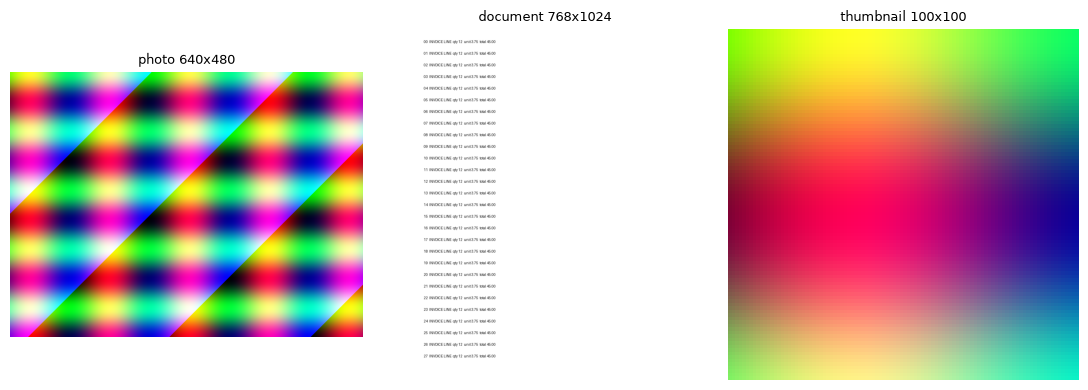

In [3]:
def make_photo(h=480, w=640):
    yy, xx = np.mgrid[0:h, 0:w]
    r = np.sin(xx / 23.0) * 127 + 128
    g = np.cos(yy / 17.0) * 127 + 128
    b = (xx + yy) % 256
    return Image.fromarray(np.stack([r, g, b], -1).astype(np.uint8))

def make_doc(h=1024, w=768):
    img = Image.new("RGB", (w, h), "white")
    d = ImageDraw.Draw(img)
    for i in range(28):
        d.text((30, 30 + i * 34), f"{i:02d}  INVOICE LINE  qty 12  unit 3.75  total 45.00", fill="black")
    return img

photo, doc = make_photo(), make_doc()
thumb = make_photo(100, 100)

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, im, t in zip(axes, [photo, doc, thumb], ["photo 640x480", "document 768x1024", "thumbnail 100x100"]):
    ax.imshow(im); ax.set_title(t, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

## 1. The budget solver, by hand

Nine lines. `factor` is "how much must I scale this image so its area equals the budget"; then both sides are floored to a multiple of `48 = patch_size × pooling_kernel_size`.

In [4]:
def my_aspect_ratio_preserving_size(height, width, patch_size, max_patches, pooling_kernel_size):
    total_px = height * width
    target_px = max_patches * (patch_size ** 2)
    factor = math.sqrt(target_px / total_px)
    side_mult = pooling_kernel_size * patch_size          # 3 * 16 = 48
    target_height = int(math.floor(factor * height / side_mult)) * side_mult
    target_width  = int(math.floor(factor * width  / side_mult)) * side_mult
    return target_height, target_width


# Check against the library over the full menu and a spread of shapes.
shapes = [(640, 480), (480, 640), (1024, 1024), (1920, 1080), (3000, 200), (224, 224), (100, 100)]
mismatches = 0
for soft in _SUPPORTED_SOFT_TOKENS:
    max_patches = soft * 3 ** 2
    for h, w in shapes:
        lib = get_aspect_ratio_preserving_size(height=h, width=w, patch_size=16,
                                               max_patches=max_patches, pooling_kernel_size=3)
        mine = my_aspect_ratio_preserving_size(h, w, 16, max_patches, 3)
        if lib != mine:
            mismatches += 1
            print(f"  MISMATCH {h}x{w} @ {soft}: lib={lib} mine={mine}")

assert mismatches == 0, "the simplified version diverges — look at the zero-dimension edge cases"
print(f"matched the library on {len(_SUPPORTED_SOFT_TOKENS) * len(shapes)} cases ✓")
print("\n(the library has extra branches for images so extreme that one side floors to 0 —")
print(" try 4000x30 to find them)")

matched the library on 35 cases ✓

(the library has extra branches for images so extreme that one side floors to 0 —
 try 4000x30 to find them)


## 2. What the budget does to real shapes

In [5]:
print(f"{'input':>12} | " + " | ".join(f"{s:>18}" for s in _SUPPORTED_SOFT_TOKENS))
print("-" * (14 + 21 * len(_SUPPORTED_SOFT_TOKENS)))
for h, w in shapes:
    cells = []
    for soft in _SUPPORTED_SOFT_TOKENS:
        mp = soft * 9
        th, tw = get_aspect_ratio_preserving_size(height=h, width=w, patch_size=16,
                                                  max_patches=mp, pooling_kernel_size=3)
        n_patches = (th // 16) * (tw // 16)
        cells.append(f"{th}x{tw} -> {n_patches // 9:4d}")
    print(f"{h}x{w:<7} | " + " | ".join(f"{c:>18}" for c in cells))

       input |                 70 |                140 |                280 |                560 |               1120
-----------------------------------------------------------------------------------------------------------------------
640x480     |    432x336 ->   63 |    624x480 ->  130 |    912x672 ->  266 |   1296x960 ->  540 |  1824x1344 -> 1064
480x640     |    336x432 ->   63 |    480x624 ->  130 |    672x912 ->  266 |   960x1296 ->  540 |  1344x1824 -> 1064
1024x1024    |    384x384 ->   64 |    528x528 ->  121 |    768x768 ->  256 |  1104x1104 ->  529 |  1584x1584 -> 1089
1920x1080    |    528x288 ->   66 |    720x384 ->  120 |   1056x576 ->  264 |   1488x816 ->  527 |  2112x1200 -> 1100
3000x200     |    1536x96 ->   64 |   2160x144 ->  135 |   3072x192 ->  256 |   4368x288 ->  546 |   6192x384 -> 1032
224x224     |    384x384 ->   64 |    528x528 ->  121 |    768x768 ->  256 |  1104x1104 ->  529 |  1584x1584 -> 1089
100x100     |    384x384 ->   64 |    528x528 ->  121 |  

Read across a row: the aspect ratio is preserved (640×480 and 480×640 give transposed targets and identical counts, the 15:1 panorama stays 15:1). Read down a column: **the budget is a target, not a cap.**

## 3. The upscaling trap

The 100×100 thumbnail is resized *up* to 768×768 and charged 256 soft tokens — the same as a 1024×1024 photo. Bicubic upsampling adds no information; it adds cost.

In [6]:
for h, w in [(100, 100), (224, 224), (1024, 1024)]:
    th, tw = get_aspect_ratio_preserving_size(height=h, width=w, patch_size=16,
                                              max_patches=280 * 9, pooling_kernel_size=3)
    n = (th // 16) * (tw // 16) // 9
    verdict = "UPSCALED" if th > h else "downscaled"
    print(f"{h:5d}x{w:<5d} -> {th}x{tw:<10} {n:4d} soft tokens   [{verdict} {th/h:.2f}x]")

print("\nIf you batch-process thumbnails or icons, pass max_soft_tokens=70 explicitly.")
print("Nothing in the API warns you about this.")

  100x100   -> 768x768         256 soft tokens   [UPSCALED 7.68x]
  224x224   -> 768x768         256 soft tokens   [UPSCALED 3.43x]
 1024x1024  -> 768x768         256 soft tokens   [downscaled 0.75x]

If you batch-process thumbnails or icons, pass max_soft_tokens=70 explicitly.
Nothing in the API warns you about this.


## 4. Patchify, by hand

Pure reshaping. A 16×16 RGB patch becomes a vector of 16·16·3 = 768 numbers.

In [7]:
def my_convert_image_to_patches(image, patch_size):
    num_channels, image_height, image_width = image.shape
    nh, nw = image_height // patch_size, image_width // patch_size
    x = image.reshape(num_channels, nh, patch_size, nw, patch_size)
    x = x.permute(1, 3, 2, 4, 0)                 # (nh, nw, ph, pw, c)
    return x.reshape(nh * nw, -1)


img = torch.randn(3, 96, 144)                    # 6 x 9 grid of patches
mine = my_convert_image_to_patches(img, 16)
lib = convert_image_to_patches(img, 16)
torch.testing.assert_close(mine, lib)
print("patchify matches the library ✓")
print("shape:", tuple(mine.shape), "= (6*9 patches, 16*16*3 values)")

patchify matches the library ✓
shape: (54, 768) = (6*9 patches, 16*16*3 values)


## 5. Run the real processor

Note the shapes: **`pixel_values` is the same size for both images despite completely different inputs.**

In [8]:
ip = Gemma4ImageProcessor()
print("defaults      :", f"patch_size={ip.patch_size}, max_soft_tokens={ip.max_soft_tokens}, "
                         f"pooling_kernel_size={ip.pooling_kernel_size}")
print("normalisation :", f"do_normalize={ip.do_normalize}, mean={ip.image_mean}, std={ip.image_std}")
print("rescale       :", f"do_rescale={ip.do_rescale}")

out = ip([photo, doc], return_tensors="pt")
for k, v in out.items():
    print(f"\n{k:26s} {tuple(v.shape)}")
print("\nnum_soft_tokens_per_image:", out["num_soft_tokens_per_image"].tolist())
print("max_patches = 280 * 3^2 =", 280 * 9)

defaults      : patch_size=16, max_soft_tokens=280, pooling_kernel_size=3
normalisation : do_normalize=False, mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0)
rescale       : do_rescale=True

pixel_values               (2, 2520, 768)

image_position_ids         (2, 2520, 2)

num_soft_tokens_per_image  (2,)

num_soft_tokens_per_image: [266, 266]
max_patches = 280 * 3^2 = 2520


In [9]:
pv = out["pixel_values"]
print(f"pixel range: [{pv.min():.4f}, {pv.max():.4f}]")
print("\nThat is [0, 1] — a plain /255, NOT ImageNet standardisation.")
print("The shift to [-1, 1] happens inside Gemma4VisionPatchEmbedder.forward:")
print("    pixel_values = 2 * (pixel_values - 0.5)")
print("\nIf you preprocess images yourself, do NOT apply the ImageNet constants.")

pixel range: [0.0000, 1.0000]

That is [0, 1] — a plain /255, NOT ImageNet standardisation.
The shift to [-1, 1] happens inside Gemma4VisionPatchEmbedder.forward:
    pixel_values = 2 * (pixel_values - 0.5)

If you preprocess images yourself, do NOT apply the ImageNet constants.


## 6. Positions: `(x, y)`, and the `-1` sentinel

`pixel_values` has a fixed shape, so the *positions* tensor is what carries each image's real size. Padding slots are marked `(-1, -1)`.

In [10]:
pos = out["image_position_ids"]
for i, name in enumerate(["photo", "doc"]):
    p = pos[i]
    is_pad = (p == -1).all(dim=-1)
    real = p[~is_pad]
    nx, ny = real[:, 0].max().item() + 1, real[:, 1].max().item() + 1
    print(f"{name:6s}: grid {nx} x {ny} = {nx*ny} patches, "
          f"{is_pad.sum().item()} padded slots ({100*is_pad.float().mean():.0f}% waste)")

print("\nfirst 5 positions of the photo:", pos[0, :5].tolist())
print("-> x varies fastest, so each row is (x, y) = (column, row), NOT (row, col).")
print("   Assume (row, col) when writing your own 2D RoPE and everything will run and be wrong.")

photo : grid 57 x 42 = 2394 patches, 126 padded slots (5% waste)
doc   : grid 42 x 57 = 2394 patches, 126 padded slots (5% waste)

first 5 positions of the photo: [[0, 0], [1, 0], [2, 0], [3, 0], [4, 0]]
-> x varies fastest, so each row is (x, y) = (column, row), NOT (row, col).
   Assume (row, col) when writing your own 2D RoPE and everything will run and be wrong.


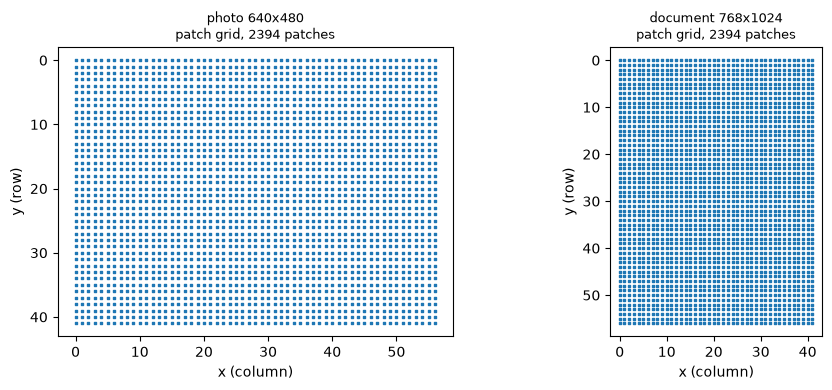

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, i, name in zip(axes, [0, 1], ["photo 640x480", "document 768x1024"]):
    p = pos[i]
    real = p[~(p == -1).all(dim=-1)]
    ax.scatter(real[:, 0], real[:, 1], s=2, marker="s")
    ax.invert_yaxis(); ax.set_aspect("equal")
    ax.set_title(f"{name}\npatch grid, {len(real)} patches", fontsize=9)
    ax.set_xlabel("x (column)"); ax.set_ylabel("y (row)")
plt.tight_layout(); plt.show()

Every 3×3 block of these squares becomes one soft token in [chapter 04](../../04-vision-tower/index.md)'s pooler — which is why both sides had to be divisible by 48 rather than merely 16.

## 7. The menu, in units of legibility

You cannot run OCR without a model, but you can measure the thing OCR depends on: how many pixels tall the text actually is after resizing.

In [12]:
print(f"{'budget':>7} | {'rendered size':>15} | {'scale':>6} | {'13pt text becomes':>18}")
print("-" * 58)
for soft in _SUPPORTED_SOFT_TOKENS:
    th, tw = get_aspect_ratio_preserving_size(height=doc.height, width=doc.width, patch_size=16,
                                              max_patches=soft * 9, pooling_kernel_size=3)
    scale = th / doc.height
    print(f"{soft:7d} | {f'{tw}x{th}':>15} | {scale:5.2f}x | {13 * scale:15.1f} px")

print("\nBelow ~8px, glyphs stop being separable. The default 280 renders this page")
print("at 0.89x — fine here, marginal for a real scan, hopeless for a footnote.")

 budget |   rendered size |  scale |  13pt text becomes
----------------------------------------------------------
     70 |         336x432 |  0.42x |             5.5 px
    140 |         480x624 |  0.61x |             7.9 px
    280 |         672x912 |  0.89x |            11.6 px
    560 |        960x1296 |  1.27x |            16.5 px
   1120 |       1344x1824 |  1.78x |            23.2 px

Below ~8px, glyphs stop being separable. The default 280 renders this page
at 0.89x — fine here, marginal for a real scan, hopeless for a footnote.


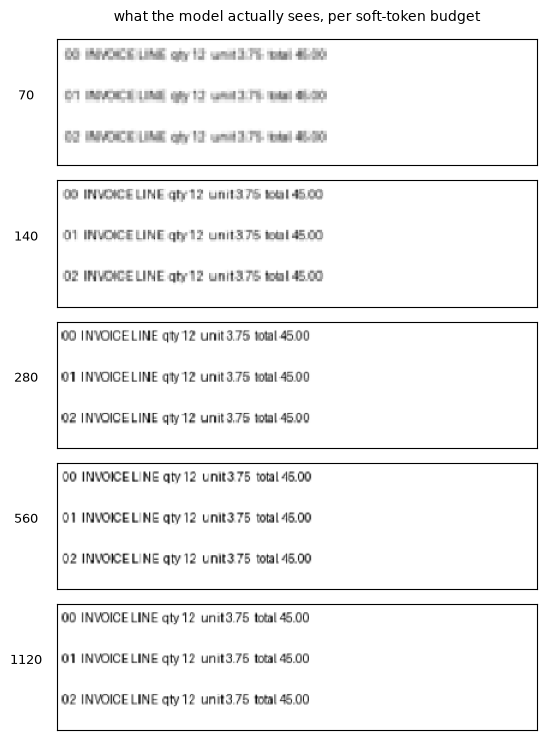

In [13]:
# See it. Crop the same region at each budget and upscale for display only.
crop_box = (25, 25, 425, 130)
fig, axes = plt.subplots(len(_SUPPORTED_SOFT_TOKENS), 1,
                         figsize=(9, 1.5 * len(_SUPPORTED_SOFT_TOKENS)))
for ax, soft in zip(axes, _SUPPORTED_SOFT_TOKENS):
    th, tw = get_aspect_ratio_preserving_size(height=doc.height, width=doc.width, patch_size=16,
                                              max_patches=soft * 9, pooling_kernel_size=3)
    resized = doc.resize((tw, th), Image.BICUBIC)
    s = th / doc.height
    box = tuple(int(v * s) for v in crop_box)
    ax.imshow(resized.crop(box).resize((crop_box[2] - crop_box[0], crop_box[3] - crop_box[1]),
                                       Image.NEAREST))
    ax.set_ylabel(f"{soft}", rotation=0, labelpad=22, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("what the model actually sees, per soft-token budget", fontsize=10)
plt.tight_layout(); plt.show()

## 8. Changing the budget

`max_soft_tokens` is validated against the menu — anything else raises.

In [14]:
for soft in (70, 1120):
    o = Gemma4ImageProcessor(max_soft_tokens=soft)([doc], return_tensors="pt")
    print(f"max_soft_tokens={soft:5d} -> pixel_values {tuple(o['pixel_values'].shape)}, "
          f"{o['num_soft_tokens_per_image'].item()} real soft tokens")

try:
    Gemma4ImageProcessor(max_soft_tokens=300)
except ValueError as e:
    print("\nValueError:", e)

max_soft_tokens=   70 -> pixel_values (1, 630, 768), 63 real soft tokens
max_soft_tokens= 1120 -> pixel_values (1, 10080, 768), 1064 real soft tokens

ValueError: `max_soft_tokens` must be one of (70, 140, 280, 560, 1120), got 300.


## Exercises

1. Find an aspect ratio extreme enough to trigger the library's zero-dimension branch, and explain what it returns.
2. For each menu entry, compute the *padding waste* (unused slots / `max_patches`) for a 16:9 image. Which budget wastes least?
3. `pixel_values` is `[B, 2520, 768]` at the default budget. Where does 2520 come from, and where does 768?
4. Take one patch out of `pixel_values` and reconstruct it as a 16×16 RGB image with `matplotlib`. Which patch of the original is it?
5. Prove to yourself that the processor does *not* apply ImageNet normalisation: feed a constant grey image and predict the output value before running it.
6. Your invoices are 200 DPI scans with 8pt print. Which budget do you need, and what does it cost per page in context tokens?

## Where next

[Chapter 04](../../04-vision-tower/index.md) takes these patches and turns them into soft tokens — patch embedding, 2D RoPE, and the coordinate-driven pooler that consumes the `(x, y)` positions you just plotted.